# Análisis Exploratorio de Datos (EDA) e Insights de Negocio

Este notebook consolida el análisis de tendencias, estacionalidad, rentabilidad y calidad de datos para la dirección de ALOHAS, usando los modelos de dbt.

## 1. Configuración de Entorno

In [58]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustar directorio al raíz si estamos en /notebooks
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

%load_ext sql
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False
%sql duckdb:///alohas.db
%sql ROLLBACK

# Configuración de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.family'] = 'sans-serif'

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


## 2. Tendencia General y Estacionalidad (Picos de Venta)

Comparamos la evolución mensual de ventas brutas (con impuestos) contra la Venta Neta Real (sin impuestos y libre de devoluciones). Esto permite evaluar el crecimiento real del negocio libre de distorsiones fiscales o comerciales.

In [59]:
%%sql df_mensual <<
SELECT 
    sales_month,
    SUM(venta_bruta_eur) AS venta_bruta,
    SUM(venta_neta_real_eur) AS venta_neta_real
FROM main.mart_channel_sales_monthly
GROUP BY 1
ORDER BY 1;

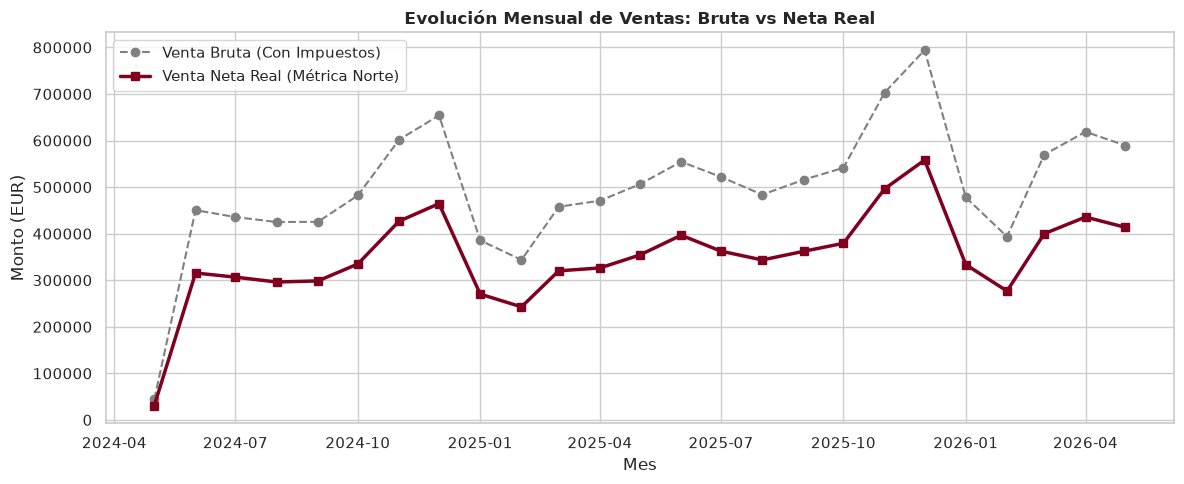

In [60]:
plt.figure()
plt.plot(df_mensual['sales_month'], df_mensual['venta_bruta'], label='Venta Bruta (Con Impuestos)', marker='o', color='gray', linestyle='--')
plt.plot(df_mensual['sales_month'], df_mensual['venta_neta_real'], label='Venta Neta Real (Métrica Norte)', marker='s', color='#800020', linewidth=2.5)
plt.title('Evolución Mensual de Ventas: Bruta vs Neta Real', fontsize=12, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Monto (EUR)')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## 3. Desempeño y Crecimiento por Canal de Ventas

Analizamos la evolución mensual de la Venta Neta Real por cada canal de comercialización (`online`, `wholesale`, `retail`, `marketplace`) para identificar focos de crecimiento y posibles fugas.

In [61]:
%%sql df_canales <<
SELECT 
    sales_month,
    channel AS canal,
    venta_neta_real_eur AS venta_neta_real
FROM main.mart_channel_sales_monthly
ORDER BY 1, 2;

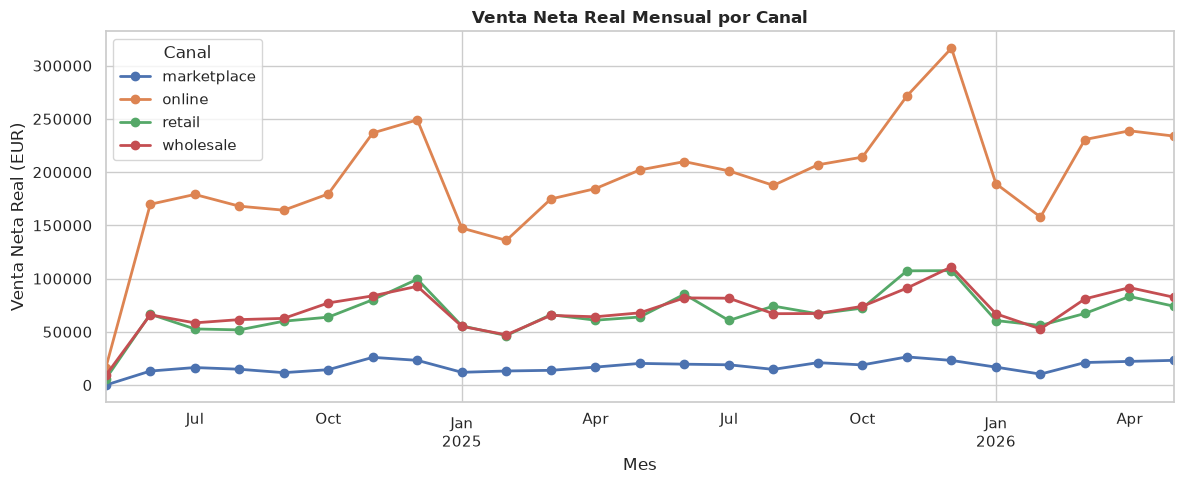

In [62]:
df_canales_pivot = df_canales.pivot(index='sales_month', columns='canal', values='venta_neta_real')
df_canales_pivot.plot(marker='o', linewidth=2)
plt.title('Venta Neta Real Mensual por Canal', fontsize=12, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Venta Neta Real (EUR)')
plt.legend(title='Canal', frameon=True)
plt.tight_layout()
plt.show()

### Tasa de Devolución Promedio por Canal
Medimos la tasa de devolución promedio acumulada para entender el impacto de la logística inversa en los distintos canales.

In [63]:
%%sql df_tasas_dev <<
SELECT 
    channel AS canal,
    SUM(total_unidades_devueltas) * 1.0 / SUM(total_unidades_vendidas) AS tasa_devolucion_promedio
FROM main.mart_channel_sales_monthly
GROUP BY 1
ORDER BY tasa_devolucion_promedio DESC;

/tmp/ipykernel_14959/2227952979.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tasas_dev, x='canal', y='tasa_devolucion_promedio', palette='viridis')


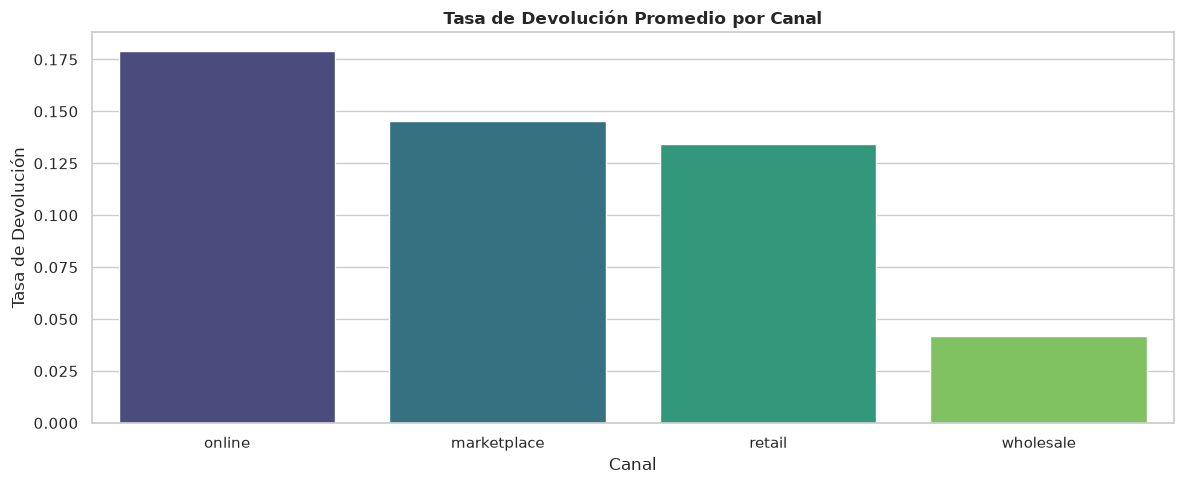

In [64]:
sns.barplot(data=df_tasas_dev, x='canal', y='tasa_devolucion_promedio', palette='viridis')
plt.title('Tasa de Devolución Promedio por Canal', fontsize=12, fontweight='bold')
plt.xlabel('Canal')
plt.ylabel('Tasa de Devolución')
plt.tight_layout()
plt.show()

## 4. Margen de Contribución por Categoría de Producto

Comparamos la facturación neta contra el Margen de Contribución real. Esto nos permite evaluar la rentabilidad real de cada línea de negocio, incorporando costos de producto, envíos prorrateados y costos operativos de devolución.

In [65]:
%%sql df_categorias <<
SELECT 
    product_category AS categoria,
    SUM(venta_neta_real_eur) AS venta_neta_real,
    SUM(margen_contribucion_eur) AS margen_contribucion
FROM main.mart_contribution_margin
GROUP BY 1
ORDER BY margen_contribucion DESC;

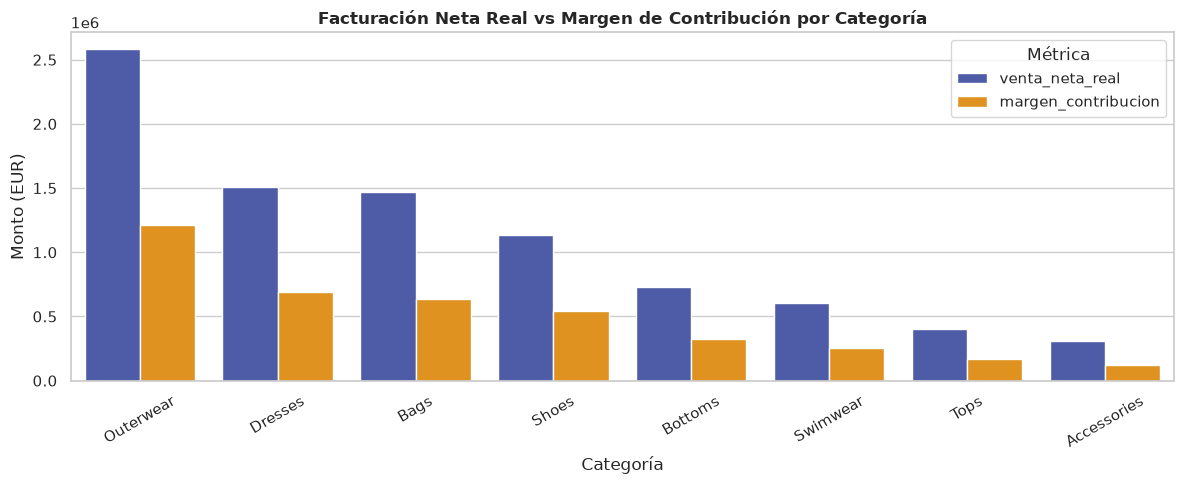

In [66]:
df_categorias_melt = df_categorias.melt(id_vars='categoria', value_vars=['venta_neta_real', 'margen_contribucion'], 
                                        var_name='Métrica', value_name='EUR')

sns.barplot(data=df_categorias_melt, x='categoria', y='EUR', hue='Métrica', palette=['#3f51b5', '#ff9800'])
plt.title('Facturación Neta Real vs Margen de Contribución por Categoría', fontsize=12, fontweight='bold')
plt.xlabel('Categoría')
plt.ylabel('Monto (EUR)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. El Desafío de los Datos Mutables: Análisis de Cohortes de Retornos

Las devoluciones en el origen se actualizan en la misma línea de venta (datos mutables). Graficar la tasa de retorno acumulada según la cohorte de la fecha de venta original nos permite ilustrar el tiempo de maduración de los datos.

In [67]:
%%sql df_cohortes <<
SELECT 
    cohorte_mes_venta,
    SUM(total_unidades_vendidas) AS unidades_vendidas,
    SUM(total_unidades_devueltas) AS unidades_devueltas,
    SUM(total_unidades_devueltas) * 1.0 / SUM(total_unidades_vendidas) AS tasa_devolucion_cohorte
FROM main.mart_sales_and_returns_cohort
GROUP BY 1
ORDER BY 1;

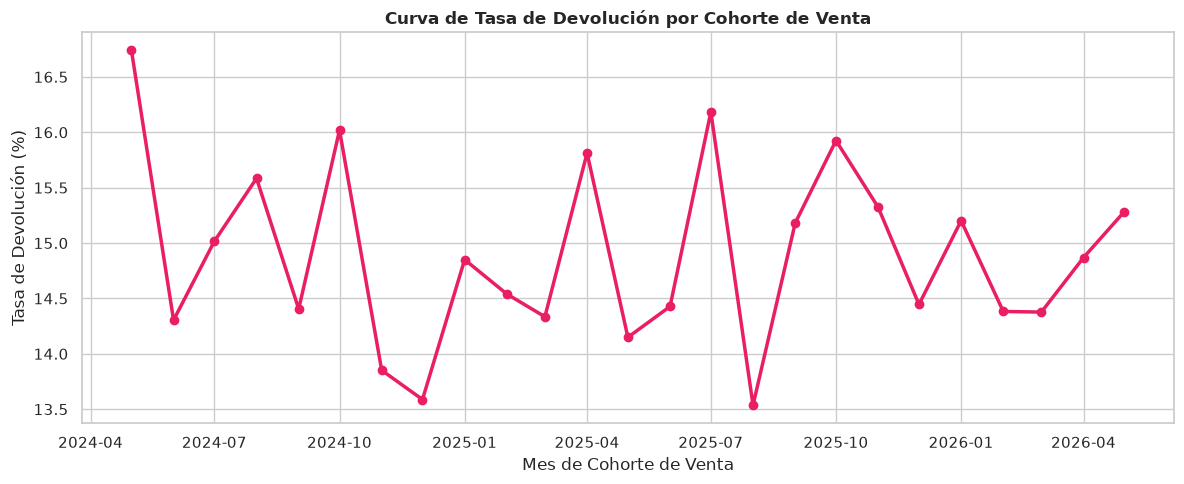

In [68]:
plt.figure()
plt.plot(df_cohortes['cohorte_mes_venta'], df_cohortes['tasa_devolucion_cohorte'] * 100, marker='o', color='#e91e63', linewidth=2.5)
plt.title('Curva de Tasa de Devolución por Cohorte de Venta', fontsize=12, fontweight='bold')
plt.xlabel('Mes de Cohorte de Venta')
plt.ylabel('Tasa de Devolución (%)')
plt.tight_layout()
plt.show()

### Defensa del Reto del Dato Mutable

* **Lo que muestra la curva:** la tasa de devolución por cohorte es prácticamente **plana** (~14-17%), incluidos los meses más recientes. Esto NO es señal de estabilidad del negocio: en este extracto sintético `quantity_returned` ya viene con su **valor final**, así que la columna mutable no deja ver la maduración.
* **La trampa real (en producción):** con la columna actualizándose in-place, los meses recientes mostrarían una tasa artificialmente **baja** (las devoluciones tardan 30-90 días en llegar) y la curva subiría sola con el tiempo, **reescribiendo el pasado**. Eso no se detecta mirando la tabla cruda: necesitas historia.
* **Decisión / diseño (ver 5b):**
  1. **As-of date of sale:** mide calidad de cohorte; en producción exige excluir los últimos ~3 meses por falta de maduración.
  2. **As-of report date:** registra la devolución como evento en su fecha real (vía snapshot → `fct_return`) para no modificar meses ya cerrados.


## 5b. Las dos definiciones de Net Sales: *as-of sale* vs *as-of report*

Con la tabla de eventos `fct_return` (cada devolución con su fecha) podemos calcular net sales atribuyendo la devolución a **dos** momentos distintos. La diferencia no es cosmética: define si el número de un mes cerrado puede cambiar o no.

- **As-of date of sale:** la devolución resta en el mes de la venta original. Mide la calidad real de la cohorte, pero **reescribe el pasado** a medida que llegan devoluciones.
- **As-of report date:** la devolución resta en el mes en que ocurre. Una vez cerrado un mes, no se vuelve a tocar — es la definición **contable** que defiendo para reporting financiero.

In [ ]:
%%sql df_timing <<
SELECT month,
       SUM(net_sales_asof_sale_eur)   AS asof_sale,
       SUM(net_sales_asof_report_eur) AS asof_report
FROM main.mart_returns_timing_monthly
GROUP BY 1
ORDER BY 1;

In [ ]:
plt.figure()
plt.plot(df_timing['month'], df_timing['asof_sale'], marker='o', linewidth=2,
         label='As-of date of sale (restata el pasado)', color='#800020')
plt.plot(df_timing['month'], df_timing['asof_report'], marker='s', linewidth=2,
         label='As-of report date (no reescribe meses cerrados)', color='#1f77b4')
plt.axhline(0, color='gray', linewidth=0.8)
plt.title('Net Sales bajo las dos definiciones de devolución', fontsize=12, fontweight='bold')
plt.xlabel('Mes'); plt.ylabel('Net Sales (EUR)')
plt.legend(frameon=True); plt.tight_layout(); plt.show()

**Cómo leer este gráfico dentro de 6 meses.** Fíjate en la cola: hay meses al final con net sales *negativo* bajo *as-of report* y cero ventas. Son devoluciones de ventas previas que aterrizan después de que el mes de venta cerró (+60 días en mi supuesto). Eso es exactamente *"el gráfico que hoy se ve correcto y mañana se mueve"*: con *as-of report* esos retornos pegan en el mes en que ocurren; con *as-of sale* se quedan en el pasado, reescribiéndolo. En este CSV sintético `quantity_returned` ya viene en su valor final, así que lo que se ilustra es la **mecánica de atribución**, no la maduración real (que el snapshot sí capturaría en producción).

## 6. Auditoría Estadística de Calidad: Detección de Valores Atípicos (IQR)

Para garantizar la confiabilidad del reporte, auditamos matemáticamente los precios de lista del catálogo usando el método del Rango Intercuartílico (IQR). Cualquier precio que supere el límite superior de la fórmula es detectado.

In [ ]:
%%sql
WITH metricas_precios AS (
    SELECT
        quantile_cont(base_price_eur, 0.25) AS Q1,
        quantile_cont(base_price_eur, 0.75) AS Q3,
        (Q3 - Q1) AS IQR,
        (Q3 + 1.5 * (Q3 - Q1)) AS limite_superior
    FROM main.stg_products
)
SELECT
    ROUND(m.limite_superior, 2)        AS limite_superior_iqr,
    ROUND(MAX(p.base_price_eur), 2)    AS precio_maximo_catalogo,
    SUM(CASE WHEN p.base_price_eur > m.limite_superior THEN 1 ELSE 0 END) AS productos_sobre_limite
FROM main.stg_products p
CROSS JOIN metricas_precios m
GROUP BY m.limite_superior;

### Conclusiones sobre Atípicos
El precio máximo del catálogo (**550€**, artículos premium de Outerwear) coincide exactamente con el límite superior del IQR: **ningún producto lo supera**. No hay errores de escala ni de digitación (precios de millones, negativos, etc.). El catálogo de precios está estadísticamente sano para el reporte directivo.